# Sprint v1 — Signal Validation Report

Phase-1 deliverable. Runs top-to-bottom on `features.parquet` and prints a
single-line `PHASE1 STATUS: PASS/FAIL` verdict against the six
falsification criteria in `sprints/v1/PRD.md`.

Sections:
1. Setup
2. Raw coverage
3. Returns distribution and autocorrelation
4. Spread time series
5. Z-score distribution and rolling stats
6. ADF and descriptive stats
7. Falsification checklist → verdict

## 1. Setup

In [1]:
import sys
from pathlib import Path

# When the notebook is run from notebooks/, pivot to project root.
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

from signals.zscore import compute_zscores

TICKERS = ['HYG', 'LQD', 'SPY', 'IEF']
SPREADS = ['hy_spread', 'ig_spread', 'hy_ig']
Z_WINDOWS = [63, 126, 252]
WARMUP = 252

feats = pd.read_parquet(ROOT / 'data/processed/features.parquet')
post = feats.iloc[WARMUP:]
print(f'features.parquet: {feats.shape}  {feats.index.min().date()} → {feats.index.max().date()}')
print(f'post-warmup:      {post.shape}')

features.parquet: (4784, 32)  2007-04-11 → 2026-04-15
post-warmup:      (4532, 32)


## 2. Raw coverage

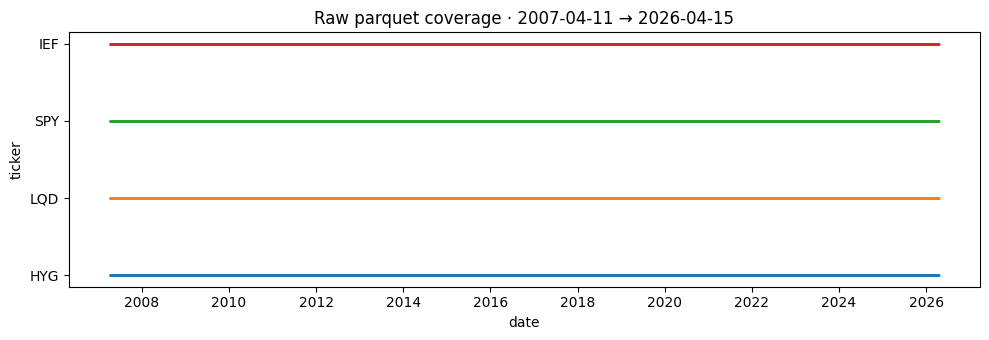

,rows,max_gap_bd,start,end
ticker,,,,
HYG,4784,2,2007-04-11,2026-04-15
LQD,4784,2,2007-04-11,2026-04-15
SPY,4784,2,2007-04-11,2026-04-15
IEF,4784,2,2007-04-11,2026-04-15


In [2]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for i, t in enumerate(TICKERS):
    df = pd.read_parquet(ROOT / f'data/raw/{t}.parquet')
    ax.scatter(df.index, np.full(len(df), i), s=0.4, label=t)
ax.set_yticks(range(len(TICKERS)))
ax.set_yticklabels(TICKERS)
start = min(pd.read_parquet(ROOT / f'data/raw/{t}.parquet').index.min() for t in TICKERS)
end = max(pd.read_parquet(ROOT / f'data/raw/{t}.parquet').index.max() for t in TICKERS)
ax.set_title(f'Raw parquet coverage · {start.date()} → {end.date()}')
ax.set_xlabel('date')
ax.set_ylabel('ticker')
plt.tight_layout(); plt.show()

# Max business-day gap per ticker
rows = []
for t in TICKERS:
    df = pd.read_parquet(ROOT / f'data/raw/{t}.parquet')
    obs = df.index.values.astype('datetime64[D]')
    gaps = np.busday_count(obs[:-1], obs[1:])
    rows.append({'ticker': t, 'rows': len(df), 'max_gap_bd': int(gaps.max() - 1),
                 'start': df.index.min().date(), 'end': df.index.max().date()})
pd.DataFrame(rows).set_index('ticker')

## 3. Returns: distribution + autocorrelation

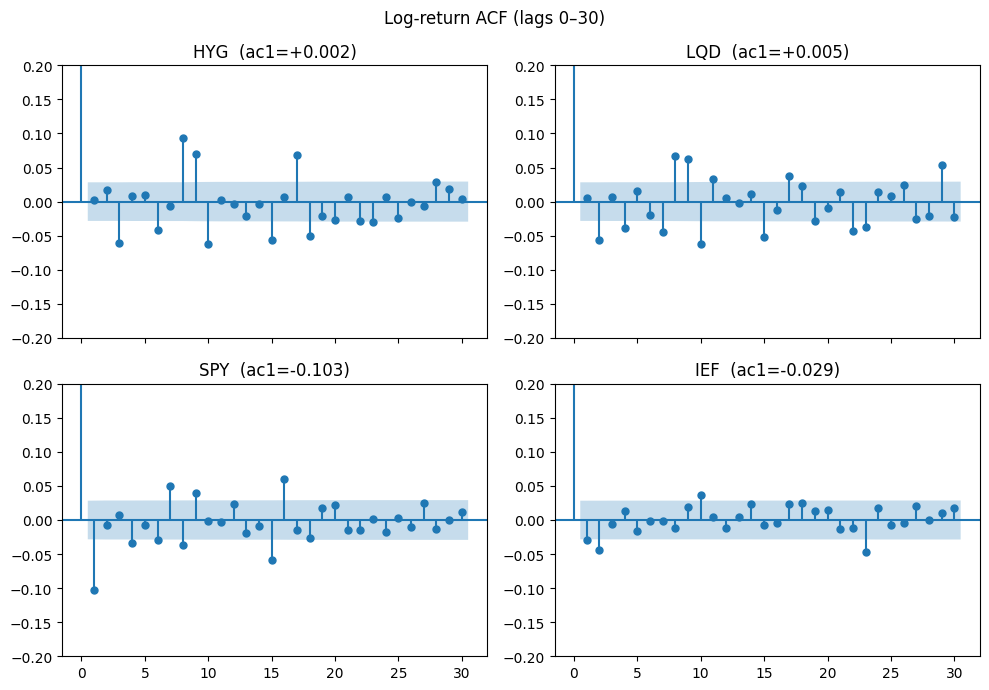

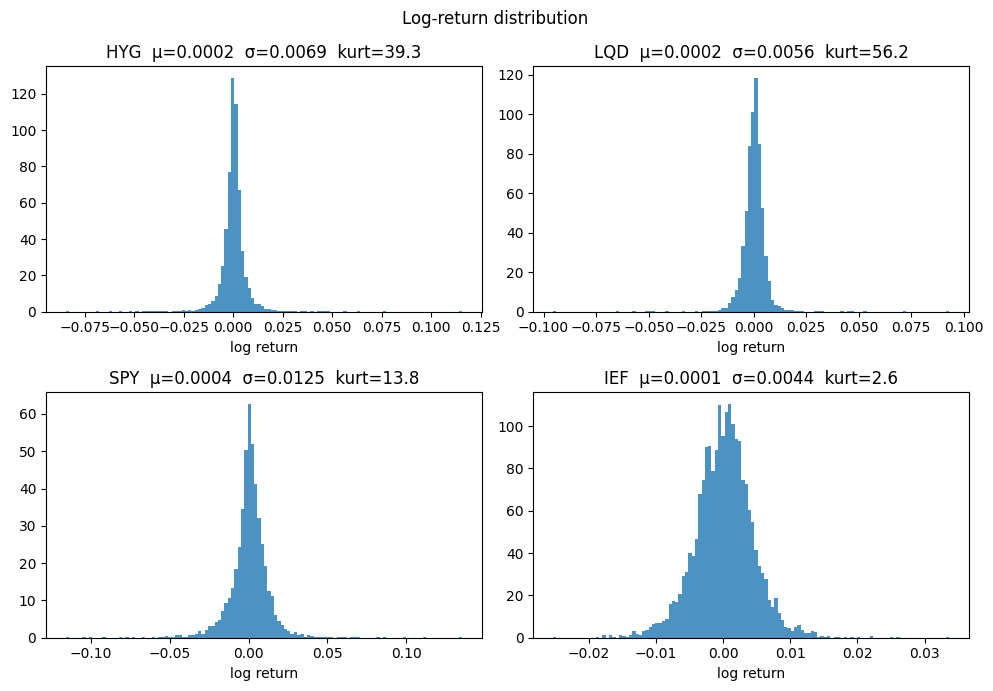

,n,mean,std,skew,kurt,ac1
ticker,,,,,,
HYG,4783,0.000193,0.006879,0.312776,39.332527,0.001869
LQD,4783,0.000163,0.005596,-0.447685,56.171727,0.005227
SPY,4783,0.000404,0.012467,-0.291895,13.822788,-0.103041
IEF,4783,0.000131,0.004399,0.112126,2.555138,-0.029271


In [3]:
fig_a, axes_a = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
fig_d, axes_d = plt.subplots(2, 2, figsize=(10, 7))
ret_rows = []
for ax_a, ax_d, t in zip(axes_a.flat, axes_d.flat, TICKERS):
    r = feats[f'{t}_log_ret'].dropna()
    ret_rows.append({'ticker': t, 'n': len(r), 'mean': r.mean(), 'std': r.std(),
                     'skew': r.skew(), 'kurt': r.kurt(), 'ac1': r.autocorr(lag=1)})
    plot_acf(r, lags=30, ax=ax_a, title=f'{t}  (ac1={r.autocorr(1):+.3f})')
    ax_a.set_ylim(-0.2, 0.2)
    ax_d.hist(r, bins=120, density=True, alpha=0.8)
    ax_d.set_title(f'{t}  μ={r.mean():.4f}  σ={r.std():.4f}  kurt={r.kurt():.1f}')
    ax_d.set_xlabel('log return')
fig_a.suptitle('Log-return ACF (lags 0–30)')
fig_d.suptitle('Log-return distribution')
fig_a.tight_layout(); fig_d.tight_layout(); plt.show()

ret_stats = pd.DataFrame(ret_rows).set_index('ticker')
ret_stats

## 4. Spread time series

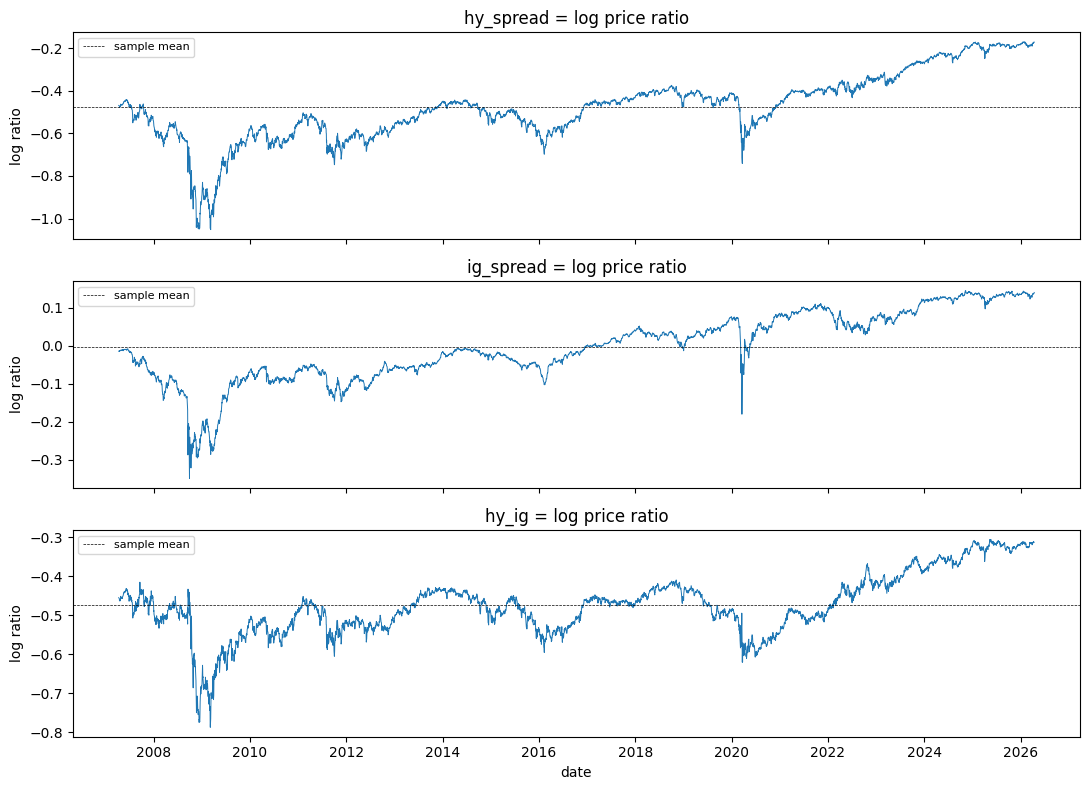

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, s in zip(axes, SPREADS):
    ax.plot(feats[s], lw=0.7)
    ax.axhline(feats[s].mean(), color='k', lw=0.5, ls='--', label='sample mean')
    ax.set_title(f'{s} = log price ratio')
    ax.set_ylabel('log ratio')
    ax.legend(loc='upper left', fontsize=8)
axes[-1].set_xlabel('date')
plt.tight_layout(); plt.show()

## 5. Z-scores: distribution + rolling stats

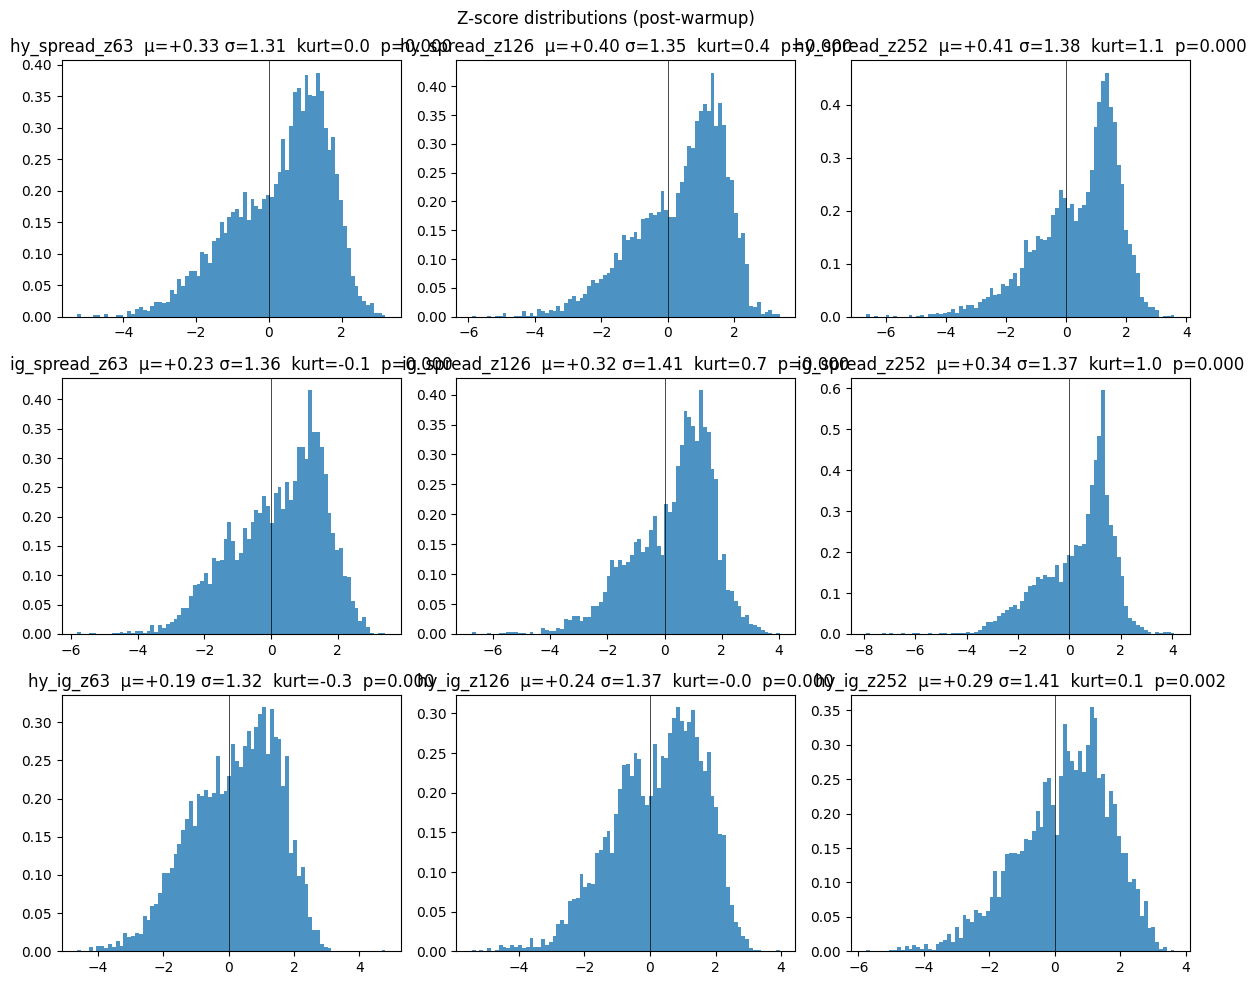

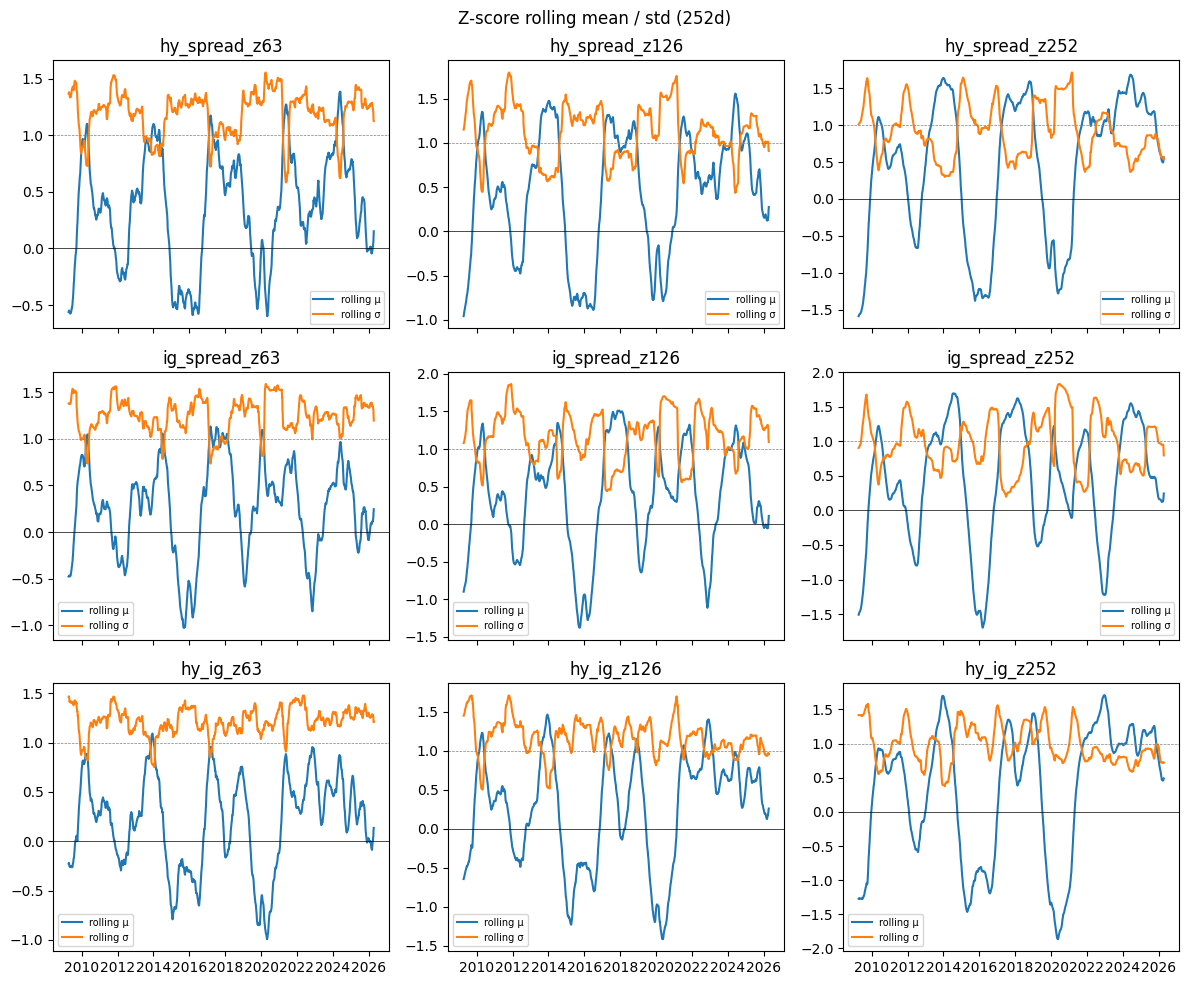

,n,mean,std,kurt,adf_p,ac1
column,,,,,,
hy_spread_z63,4532,0.325948,1.314561,0.029584,1.660599e-17,0.946340
hy_spread_z126,4532,0.398495,1.351836,0.415282,3.800404e-10,0.970887
hy_spread_z252,4532,0.410559,1.380639,1.106279,3.576202e-04,0.984414
ig_spread_z63,4532,0.229381,1.359645,-0.082174,5.974786e-16,0.960820
ig_spread_z126,4532,0.317303,1.408282,0.683092,1.304937e-08,0.978703
ig_spread_z252,4532,0.344796,1.369788,1.009513,6.557999e-05,0.988508
hy_ig_z63,4532,0.192580,1.315298,-0.336913,2.697986e-16,0.935289
hy_ig_z126,4532,0.236668,1.367163,-0.037364,1.444251e-08,0.961297
hy_ig_z252,4532,0.287420,1.407675,0.122160,1.977199e-03,0.981800


In [5]:
fig_d, axes_d = plt.subplots(3, 3, figsize=(12, 10))
fig_r, axes_r = plt.subplots(3, 3, figsize=(12, 10), sharex=True)
z_rows = []
for i, s in enumerate(SPREADS):
    for j, w in enumerate(Z_WINDOWS):
        col = f'{s}_z{w}'
        z = post[col].dropna()
        adf_p = adfuller(z, autolag='AIC')[1]
        z_rows.append({'column': col, 'n': len(z), 'mean': z.mean(), 'std': z.std(),
                       'kurt': z.kurt(), 'adf_p': adf_p, 'ac1': z.autocorr(1)})
        axd = axes_d[i, j]
        axd.hist(z, bins=80, density=True, alpha=0.8)
        axd.set_title(f'{col}  μ={z.mean():+.2f} σ={z.std():.2f}  kurt={z.kurt():.1f}  p={adf_p:.3f}')
        axd.axvline(0, color='k', lw=0.5)
        axr = axes_r[i, j]
        axr.plot(post[col].rolling(252).mean(), label='rolling μ')
        axr.plot(post[col].rolling(252).std(),  label='rolling σ')
        axr.axhline(0, color='k', lw=0.5); axr.axhline(1, color='gray', lw=0.5, ls='--')
        axr.set_title(col); axr.legend(fontsize=7)
fig_d.suptitle('Z-score distributions (post-warmup)')
fig_r.suptitle('Z-score rolling mean / std (252d)')
fig_d.tight_layout(); fig_r.tight_layout(); plt.show()

z_stats = pd.DataFrame(z_rows).set_index('column')
z_stats

## 6. Baseline comparison — z-scores of shuffled spreads

In [6]:
rng = np.random.default_rng(7)
shuffled = pd.DataFrame(index=feats.index)
for s in SPREADS:
    vals = feats[s].dropna().values.copy()
    rng.shuffle(vals)
    ser = pd.Series(np.nan, index=feats.index)
    ser.iloc[-len(vals):] = vals
    shuffled[s] = ser
b = compute_zscores(shuffled, SPREADS, [252]).iloc[WARMUP:]
base_rows = []
for c in b.columns:
    x = b[c].dropna()
    adf_p = adfuller(x, autolag='AIC')[1]
    base_rows.append({'column': c, 'mean': x.mean(), 'std': x.std(),
                      'kurt': x.kurt(), 'adf_p': adf_p})
pd.DataFrame(base_rows).set_index('column')

,mean,std,kurt,adf_p
column,,,,
hy_spread_z252,-0.005760,0.999961,0.787948,0.0
ig_spread_z252,-0.003803,0.997447,0.100719,0.0
hy_ig_z252,-0.002294,1.001463,0.849064,0.0


## 7. Falsification checklist → verdict

In [7]:
checks = []

# C1 — no NaNs post-warmup
c1 = int(post.isna().sum().sum()) == 0
checks.append(('C1 no NaNs post-warmup', c1))

# C2 — ADF p < 0.05 on all z-scores
c2 = bool((z_stats['adf_p'] < 0.05).all())
checks.append(('C2 ADF p < 0.05 (all 9 z-scores)', c2))

# C3 — z-score mean in [-0.2, 0.2], std in [0.8, 1.2]
mean_ok = (z_stats['mean'].between(-0.2, 0.2)).all()
std_ok  = (z_stats['std'].between(0.8, 1.2)).all()
c3 = bool(mean_ok and std_ok)
checks.append(('C3 z-score mean ∈ [-0.2,0.2] and std ∈ [0.8,1.2]', c3))

# C4 — kurtosis < 20
c4 = bool((z_stats['kurt'] < 20).all())
checks.append(('C4 z-score kurtosis < 20', c4))

# C5 — max business-day gap ≤ 5 per ticker
gap_max = 0
for t in TICKERS:
    df = pd.read_parquet(ROOT / f'data/raw/{t}.parquet')
    obs = df.index.values.astype('datetime64[D]')
    gap_max = max(gap_max, int(np.busday_count(obs[:-1], obs[1:]).max() - 1))
c5 = gap_max <= 5
checks.append((f'C5 max business-day gap ≤ 5 (observed {gap_max})', c5))

# C6 — row-count conservation (every raw ticker has the same count that
#      appears in features via the inner-join on adj_close)
raw_counts = [len(pd.read_parquet(ROOT / f'data/raw/{t}.parquet')) for t in TICKERS]
c6 = bool(len(set(raw_counts + [len(feats)])) == 1)
checks.append((f'C6 row counts conserved ({raw_counts} → {len(feats)})', c6))

for name, ok in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {name}")

verdict = 'PASS' if all(ok for _, ok in checks) else 'FAIL'
print()
print(f'PHASE1 STATUS: {verdict}')

  PASS  C1 no NaNs post-warmup
  PASS  C2 ADF p < 0.05 (all 9 z-scores)
  FAIL  C3 z-score mean ∈ [-0.2,0.2] and std ∈ [0.8,1.2]
  PASS  C4 z-score kurtosis < 20
  PASS  C5 max business-day gap ≤ 5 (observed 2)
  PASS  C6 row counts conserved ([4784, 4784, 4784, 4784] → 4784)

PHASE1 STATUS: FAIL
